16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
Best weight for RF: 0.0, LSTM: 1.0, R²: 0.5367
{'Model': 'Random Forest', 'R² Score': -0.6457, 'MSE': 0.056437}
{'Model': 'LSTM', 'R² Score': 0.5367, 'MSE': 0.015889}
{'Model': 'Weighted Ensemble', 'R² Score': -31.9121, 'MSE': 1.128667}
{'Model': 'XGBoost Meta-Model', 'R² Score': -3.7794, 'MSE': 0.032083}


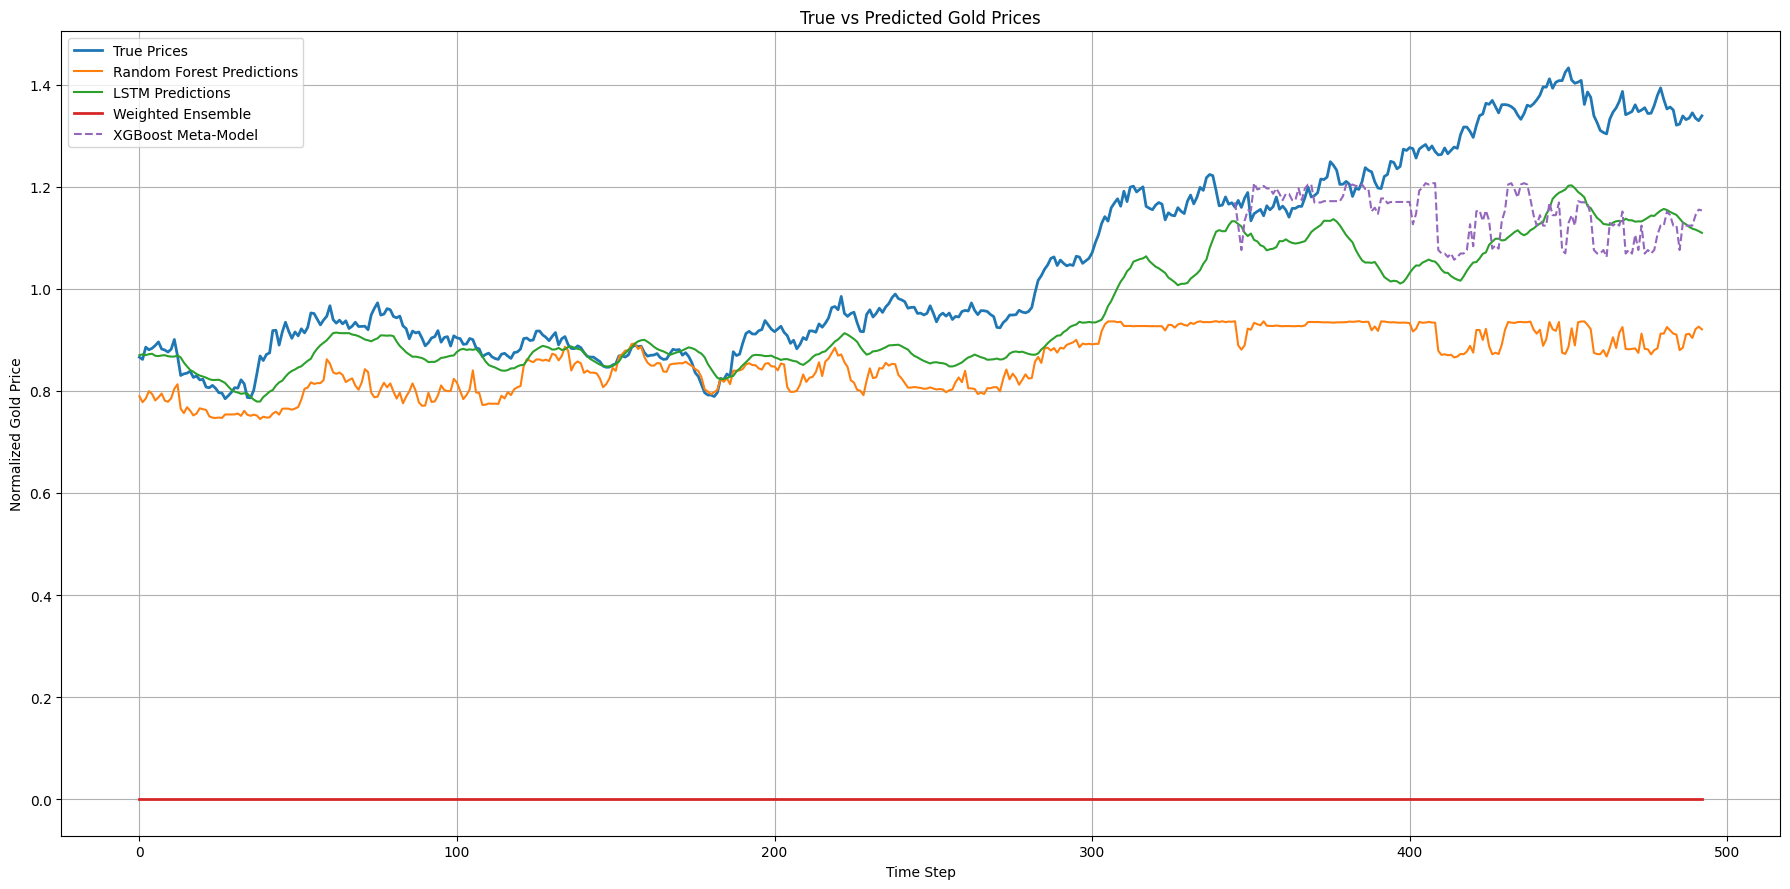

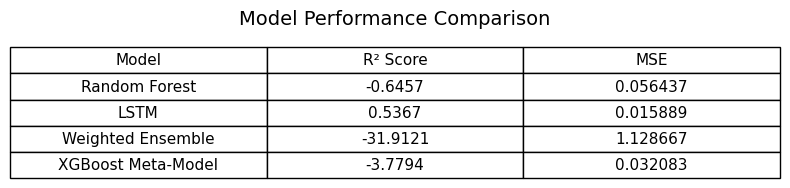

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
from keras.models import Sequential
from keras.layers import LSTM, Dense
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore")


df = pd.read_csv(r'C:\Users\User\dev\training_model\dataset\modified_financial_data.csv')
df['Date'] = pd.to_datetime(df['Date'])
df.sort_values('Date', inplace=True)
df.rename(columns={"^GSPC": "SPX", "EURUSD=X": "EUR/USD"}, inplace=True)
df['GLD'] = np.log1p(df['GLD']) #--- log transforming can stabilize variance and improve modeling of the data 

features = ['SPX', 'USO', 'SLV', 'EUR/USD']
target = 'GLD'


split_index = int(len(df) * 0.8)
train_df, test_df = df.iloc[:split_index], df.iloc[split_index:]


scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train = scaler_X.fit_transform(train_df[features])
X_test = scaler_X.transform(test_df[features])
y_train = scaler_y.fit_transform(train_df[[target]])
y_test = scaler_y.transform(test_df[[target]])


rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train.ravel())
rf_preds = rf.predict(X_test)


def create_sequences(df_seq, features, target_col, n_steps, scaler_X, scaler_y):
    X_scaled = scaler_X.transform(df_seq[features])
    y_scaled = scaler_y.transform(df_seq[[target_col]])

    X_seq, y_seq = [], []
    for i in range(n_steps, len(df_seq)):
        X_seq.append(X_scaled[i - n_steps:i])
        y_seq.append(y_scaled[i])
    return np.array(X_seq), np.array(y_seq)


n_steps = 10
X_lstm_train, y_lstm_train = create_sequences(train_df, features, target, n_steps, scaler_X, scaler_y)
X_lstm_test, y_lstm_test = create_sequences(test_df, features, target, n_steps, scaler_X, scaler_y)


model_lstm = Sequential([
    LSTM(50, input_shape=(n_steps, len(features))),
    Dense(1)
])
model_lstm.compile(optimizer='adam', loss='mse')
model_lstm.fit(X_lstm_train, y_lstm_train, epochs=20, batch_size=16, verbose=0)
lstm_preds = model_lstm.predict(X_lstm_test).ravel()


min_len = min(len(rf_preds), len(lstm_preds), len(y_test))
rf_preds = rf_preds[-min_len:]
lstm_preds = lstm_preds[-min_len:]
y_true = y_test[-min_len:].ravel()


meta_X = np.column_stack((rf_preds, lstm_preds))
meta_y = y_true

meta_X_train, meta_X_val, meta_y_train, meta_y_val = train_test_split(
    meta_X, meta_y, test_size=0.3, shuffle=False  # no shuffle for time series
)

meta_model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
meta_model.fit(meta_X_train, meta_y_train)
xgb_preds = meta_model.predict(meta_X_val)


best_score = -np.inf
best_w = 0
for w in np.linspace(0, 1, 21):  
    blended = w * rf_preds + (1 - w) * lstm_preds
    score = r2_score(y_true, blended)
    if score > best_score:
        best_score = score
        best_w = w

print(f"Best weight for RF: {round(best_w, 2)}, LSTM: {round(1 - best_w, 2)}, R²: {round(best_score, 4)}")

combined_preds = 0.25 * best_w + best_w * lstm_preds


def evaluate_model(name, y_true, preds):
    res =  {
        'Model': name,
        'R² Score': round(r2_score(y_true, preds), 4),
        'MSE': round(mean_squared_error(y_true, preds), 6)
    }

    print(res)
    return res


metrics = [
    evaluate_model("Random Forest", y_true, rf_preds),
    evaluate_model("LSTM", y_true, lstm_preds),
    evaluate_model("Weighted Ensemble", y_true, combined_preds),
    evaluate_model("XGBoost Meta-Model", meta_y_val, xgb_preds)
]


plt.figure(figsize=(18, 9))
plt.plot(y_true, label='True Prices', linewidth=2)
plt.plot(rf_preds, label='Random Forest Predictions')
plt.plot(lstm_preds, label='LSTM Predictions')
plt.plot(combined_preds, label='Weighted Ensemble', linewidth=2)
plt.plot(range(len(y_true) - len(xgb_preds), len(y_true)), xgb_preds, label='XGBoost Meta-Model', linestyle='--')
plt.title('True vs Predicted Gold Prices')
plt.xlabel('Time Step')
plt.ylabel('Normalized Gold Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


fig, ax = plt.subplots(figsize=(8, 2))
ax.axis('off')
table_data = [(m['Model'], m['R² Score'], m['MSE']) for m in metrics]
table = ax.table(cellText=table_data, colLabels=["Model", "R² Score", "MSE"],
                 cellLoc='center', loc='center')
table.scale(1, 2)
table.set_fontsize(12)
plt.title("Model Performance Comparison", fontsize=14, pad=20)
plt.tight_layout()
plt.show()


In [2]:
#--- empowering the lstm

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step
Best weight for RF: 1.0, LSTM: 0.0, R²: -0.6457
{'Model': 'Random Forest', 'R² Score': -0.6457, 'MSE': 0.056437}
{'Model': 'LSTM', 'R² Score': -0.9603, 'MSE': 0.067227}
{'Model': 'Weighted Ensemble', 'R² Score': 0.2437, 'MSE': 0.025935}
{'Model': 'XGBoost Meta-Model', 'R² Score': -7.2588, 'MSE': 0.055439}


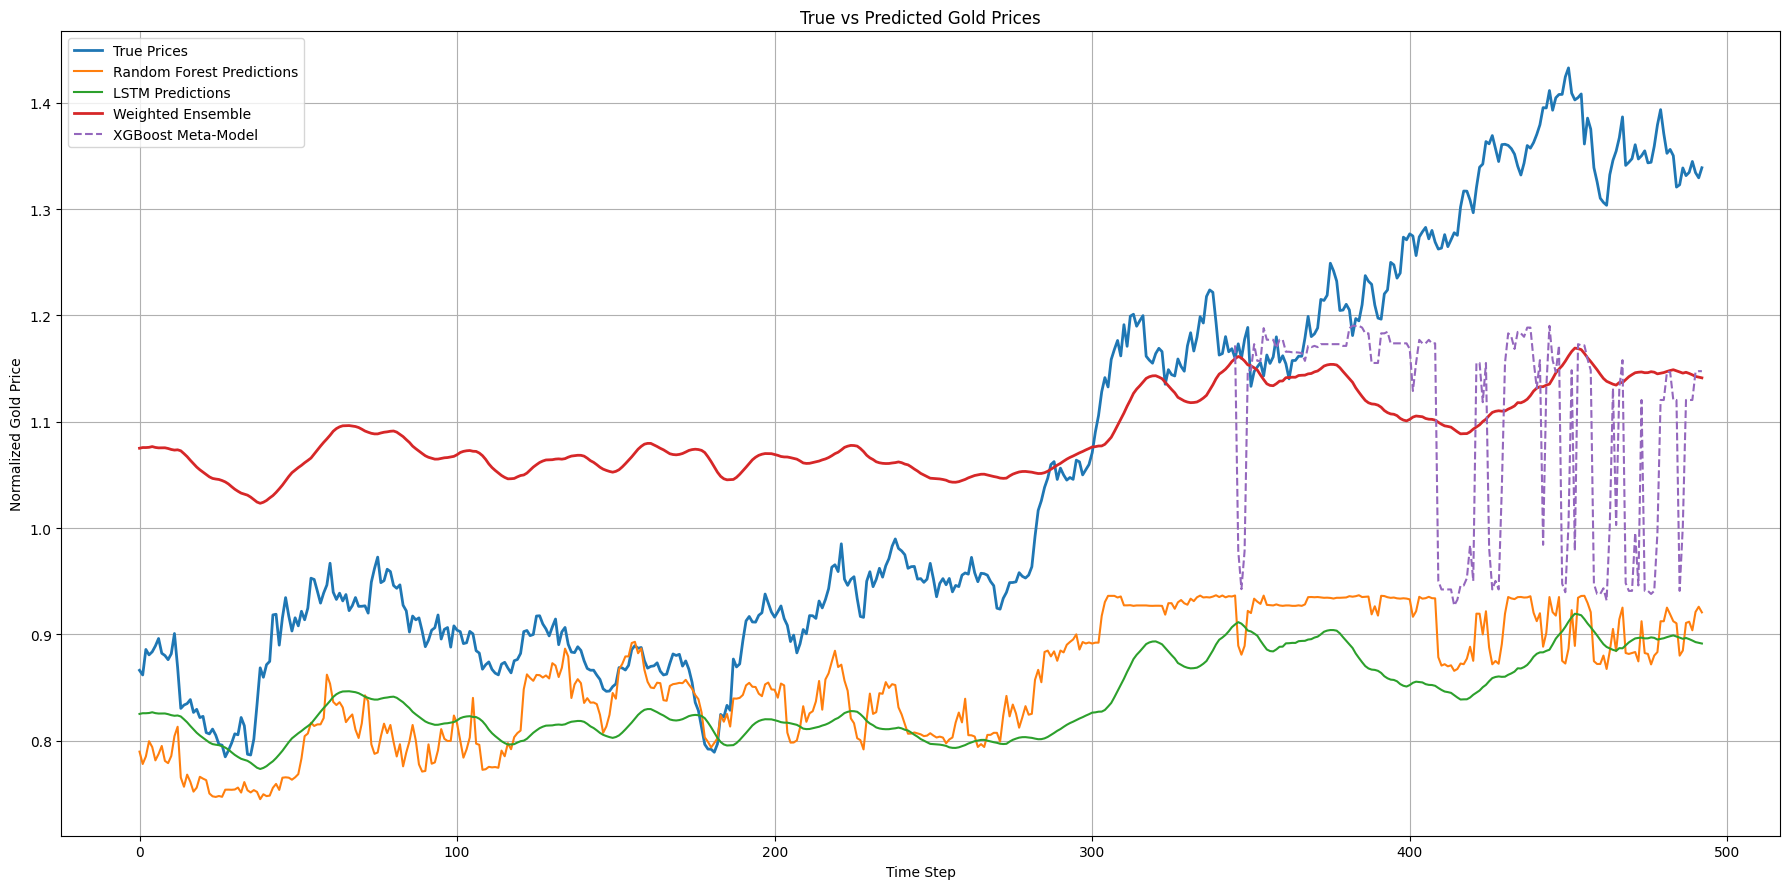

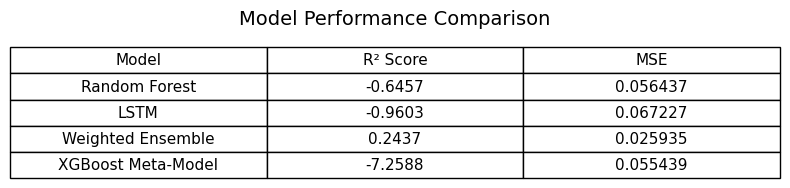

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore")


df = pd.read_csv(r'C:\Users\User\dev\training_model\dataset\modified_financial_data.csv')
df['Date'] = pd.to_datetime(df['Date'])
df.sort_values('Date', inplace=True)
df.rename(columns={"^GSPC": "SPX", "EURUSD=X": "EUR/USD"}, inplace=True)
df['GLD'] = np.log1p(df['GLD']) #--- log transforming can stabilize variance and improve modeling of the data 

features = ['SPX', 'USO', 'SLV', 'EUR/USD']
target = 'GLD'

for lag in range(1, 4):
    for col in features + [target]:
        df[f"{col}_lag{lag}"] = df[col].shift(lag)


split_index = int(len(df) * 0.8)
train_df, test_df = df.iloc[:split_index], df.iloc[split_index:]


scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train = scaler_X.fit_transform(train_df[features])
X_test = scaler_X.transform(test_df[features])
y_train = scaler_y.fit_transform(train_df[[target]])
y_test = scaler_y.transform(test_df[[target]])


rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train.ravel())
rf_preds = rf.predict(X_test)


def create_sequences(df_seq, features, target_col, n_steps, scaler_X, scaler_y):
    X_scaled = scaler_X.transform(df_seq[features])
    y_scaled = scaler_y.transform(df_seq[[target_col]])

    X_seq, y_seq = [], []
    for i in range(n_steps, len(df_seq)):
        X_seq.append(X_scaled[i - n_steps:i])
        y_seq.append(y_scaled[i])
    return np.array(X_seq), np.array(y_seq)


n_steps = 10
n_features = len(features)
X_lstm_train, y_lstm_train = create_sequences(train_df, features, target, n_steps, scaler_X, scaler_y)
X_lstm_test, y_lstm_test = create_sequences(test_df, features, target, n_steps, scaler_X, scaler_y)


model_lstm = Sequential([
    LSTM(64, return_sequences=True, input_shape=(n_steps, n_features)),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1)
])
model_lstm.compile(optimizer='adam', loss='mse')
model_lstm.fit(X_lstm_train, y_lstm_train, epochs=20, batch_size=16, verbose=0)
lstm_preds = model_lstm.predict(X_lstm_test).ravel()


min_len = min(len(rf_preds), len(lstm_preds), len(y_test))
rf_preds = rf_preds[-min_len:]
lstm_preds = lstm_preds[-min_len:]
y_true = y_test[-min_len:].ravel()


meta_X = np.column_stack((rf_preds, lstm_preds))
meta_y = y_true

meta_X_train, meta_X_val, meta_y_train, meta_y_val = train_test_split(
    meta_X, meta_y, test_size=0.3, shuffle=False  # no shuffle for time series
)

meta_model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
meta_model.fit(meta_X_train, meta_y_train)
xgb_preds = meta_model.predict(meta_X_val)


best_score = -np.inf
best_w = 0
for w in np.linspace(0, 1, 21):  
    blended = w * rf_preds + (1 - w) * lstm_preds
    score = r2_score(y_true, blended)
    if score > best_score:
        best_score = score
        best_w = w

print(f"Best weight for RF: {round(best_w, 2)}, LSTM: {round(1 - best_w, 2)}, R²: {round(best_score, 4)}")

combined_preds = 0.25 * best_w + best_w * lstm_preds


def evaluate_model(name, y_true, preds):
    res =  {
        'Model': name,
        'R² Score': round(r2_score(y_true, preds), 4),
        'MSE': round(mean_squared_error(y_true, preds), 6)
    }

    print(res)
    return res


metrics = [
    evaluate_model("Random Forest", y_true, rf_preds),
    evaluate_model("LSTM", y_true, lstm_preds),
    evaluate_model("Weighted Ensemble", y_true, combined_preds),
    evaluate_model("XGBoost Meta-Model", meta_y_val, xgb_preds)
]


plt.figure(figsize=(18, 9))
plt.plot(y_true, label='True Prices', linewidth=2)
plt.plot(rf_preds, label='Random Forest Predictions')
plt.plot(lstm_preds, label='LSTM Predictions')
plt.plot(combined_preds, label='Weighted Ensemble', linewidth=2)
plt.plot(range(len(y_true) - len(xgb_preds), len(y_true)), xgb_preds, label='XGBoost Meta-Model', linestyle='--')
plt.title('True vs Predicted Gold Prices')
plt.xlabel('Time Step')
plt.ylabel('Normalized Gold Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


fig, ax = plt.subplots(figsize=(8, 2))
ax.axis('off')
table_data = [(m['Model'], m['R² Score'], m['MSE']) for m in metrics]
table = ax.table(cellText=table_data, colLabels=["Model", "R² Score", "MSE"],
                 cellLoc='center', loc='center')
table.scale(1, 2)
table.set_fontsize(12)
plt.title("Model Performance Comparison", fontsize=14, pad=20)
plt.tight_layout()
plt.show()


In [4]:
#--- using bi-directional lstm

Epoch 1/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - loss: 0.0470 - val_loss: 0.0154
Epoch 2/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0104 - val_loss: 0.0143
Epoch 3/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0086 - val_loss: 0.0124
Epoch 4/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0076 - val_loss: 0.0123
Epoch 5/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0063 - val_loss: 0.0136
Epoch 6/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0058 - val_loss: 0.0102
Epoch 7/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0057 - val_loss: 0.0049
Epoch 8/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0051 - val_loss: 0.0073
Epoch 9/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0048 - val_loss: 0.0060
Epoch 10/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0049 - val_loss: 0.0036
Epoch 11/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0046 - val_loss: 0.0045
Epoch 12/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.

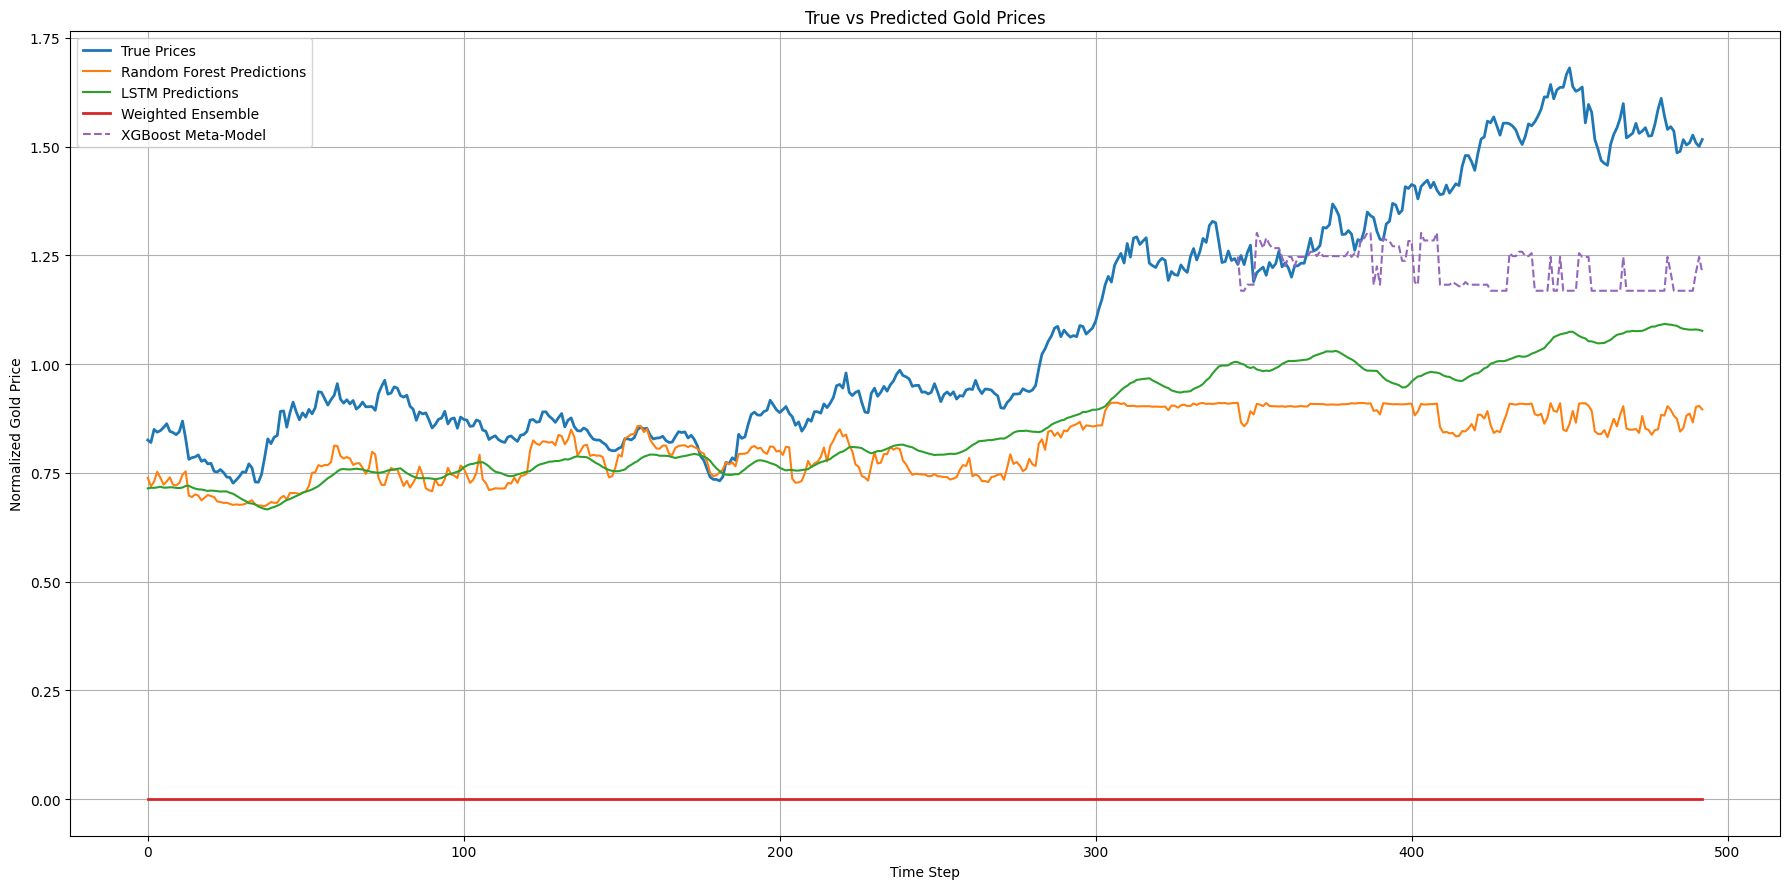

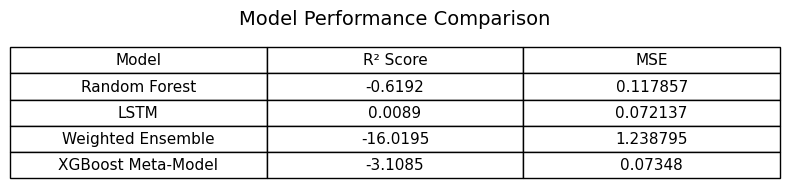

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout, Bidirectional
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
import warnings
from keras.callbacks import EarlyStopping
warnings.filterwarnings("ignore")


df = pd.read_csv(r'C:\Users\User\dev\training_model\dataset\modified_financial_data.csv')
df['Date'] = pd.to_datetime(df['Date'])
df.sort_values('Date', inplace=True)
df.rename(columns={"^GSPC": "SPX", "EURUSD=X": "EUR/USD"}, inplace=True)
# df['GLD'] = np.log1p(df['GLD']) #--- log transforming can stabilize variance and improve modeling of the data 

features = ['SPX', 'USO', 'SLV', 'EUR/USD']
target = 'GLD'

for lag in range(1, 4):
    for col in features + [target]:
        df[f"{col}_lag{lag}"] = df[col].shift(lag)


split_index = int(len(df) * 0.8)
train_df, test_df = df.iloc[:split_index], df.iloc[split_index:]


scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train = scaler_X.fit_transform(train_df[features])
X_test = scaler_X.transform(test_df[features])
y_train = scaler_y.fit_transform(train_df[[target]])
y_test = scaler_y.transform(test_df[[target]])


rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train.ravel())
rf_preds = rf.predict(X_test)


def create_sequences(df_seq, features, target_col, n_steps, scaler_X, scaler_y):
    X_scaled = scaler_X.transform(df_seq[features])
    y_scaled = scaler_y.transform(df_seq[[target_col]])

    X_seq, y_seq = [], []
    for i in range(n_steps, len(df_seq)):
        X_seq.append(X_scaled[i - n_steps:i])
        y_seq.append(y_scaled[i])
    return np.array(X_seq), np.array(y_seq)


n_steps = X_lstm_train.shape[1]
n_features = X_lstm_train.shape[2]
X_lstm_train, y_lstm_train = create_sequences(train_df, features, target, n_steps, scaler_X, scaler_y)
X_lstm_test, y_lstm_test = create_sequences(test_df, features, target, n_steps, scaler_X, scaler_y)


model_lstm = Sequential([
    Bidirectional(LSTM(64, return_sequences=True), input_shape=(n_steps, n_features)),
    Dropout(0.2),
    Bidirectional(LSTM(32)),
    Dropout(0.2),
    Dense(1)
])

model_lstm.compile(optimizer='adam', loss='mse')
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
model_lstm.fit(
    X_lstm_train, y_lstm_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)
lstm_preds = model_lstm.predict(X_lstm_test).ravel()


min_len = min(len(rf_preds), len(lstm_preds), len(y_test))
rf_preds = rf_preds[-min_len:]
lstm_preds = lstm_preds[-min_len:]
y_true = y_test[-min_len:].ravel()


meta_X = np.column_stack((rf_preds, lstm_preds))
meta_y = y_true

meta_X_train, meta_X_val, meta_y_train, meta_y_val = train_test_split(
    meta_X, meta_y, test_size=0.3, shuffle=False  # no shuffle for time series
)

meta_model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
meta_model.fit(meta_X_train, meta_y_train)
xgb_preds = meta_model.predict(meta_X_val)


best_score = -np.inf
best_w = 0
for w in np.linspace(0, 1, 21):  
    blended = w * rf_preds + (1 - w) * lstm_preds
    score = r2_score(y_true, blended)
    if score > best_score:
        best_score = score
        best_w = w

print(f"Best weight for RF: {round(best_w, 2)}, LSTM: {round(1 - best_w, 2)}, R²: {round(best_score, 4)}")

combined_preds = 0.25 * best_w + best_w * lstm_preds


def evaluate_model(name, y_true, preds):
    res =  {
        'Model': name,
        'R² Score': round(r2_score(y_true, preds), 4),
        'MSE': round(mean_squared_error(y_true, preds), 6)
    }

    print(res)
    return res


metrics = [
    evaluate_model("Random Forest", y_true, rf_preds),
    evaluate_model("LSTM", y_true, lstm_preds),
    evaluate_model("Weighted Ensemble", y_true, combined_preds),
    evaluate_model("XGBoost Meta-Model", meta_y_val, xgb_preds)
]


plt.figure(figsize=(18, 9))
plt.plot(y_true, label='True Prices', linewidth=2)
plt.plot(rf_preds, label='Random Forest Predictions')
plt.plot(lstm_preds, label='LSTM Predictions')
plt.plot(combined_preds, label='Weighted Ensemble', linewidth=2)
plt.plot(range(len(y_true) - len(xgb_preds), len(y_true)), xgb_preds, label='XGBoost Meta-Model', linestyle='--')
plt.title('True vs Predicted Gold Prices')
plt.xlabel('Time Step')
plt.ylabel('Normalized Gold Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


fig, ax = plt.subplots(figsize=(8, 2))
ax.axis('off')
table_data = [(m['Model'], m['R² Score'], m['MSE']) for m in metrics]
table = ax.table(cellText=table_data, colLabels=["Model", "R² Score", "MSE"],
                 cellLoc='center', loc='center')
table.scale(1, 2)
table.set_fontsize(12)
plt.title("Model Performance Comparison", fontsize=14, pad=20)
plt.tight_layout()
plt.show()
